# Optimization

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from scipy.optimize import fmin, minimize, differential_evolution

In [2]:
# Load dataframes from binary files
base_dir = r'D:\Entwicklungen\share\DataScienceProject\sep24_cds_int_us-welding'

ft_param_path = os.path.join(base_dir, 'ft_files', '03_feat_parameters.ft')
df_params = pd.read_feather(ft_param_path)

dump_dir = os.path.join(base_dir, 'model_dumps')

In [3]:
# List of parameters
lst_param = df_params.columns.to_list()

lst_var = lst_param[1:4] + lst_param[5:7] + lst_param[8:24]
lst_nb_slots = [lst_param[4]] + [lst_param[7]]
lst_calc = lst_param[32:34]
lst_slot_class = lst_param[541:545]
lst_cols = lst_var + lst_calc + lst_slot_class

In [4]:
X = df_params[lst_cols]

In [5]:
# Get indices of Train-Test split
X_train, X_test, _, _ = train_test_split(X, X, test_size=0.2, random_state=55)
idx_train = X_train.index
idx_test = X_test.index

Target variables

In [6]:
## Long displacements
y_nrdd = df_params['long_disp_nrdd']
y_nrdd_train = y_nrdd.loc[idx_train]
y_nrdd_test = y_nrdd.loc[idx_test]

In [7]:
## All Frequencies
lst_freq = lst_param[86:122]
Y_freq = df_params[lst_freq]
Y_freq_test = Y_freq.loc[idx_test]

In [8]:
## Long frequencies
y_longfreq = df_params['freq_long']
y_longfreq_test = y_longfreq.loc[idx_test]

### Load the ML models

Long displacements

In [9]:
transf_longdisp = pickle.load(open(os.path.join(dump_dir, '5_model_neuralnetw_tuned_transformer.pkl'), 'rb'))
pipe_tuned_longdisp = pickle.load(open(os.path.join(dump_dir, '5_model_neuralnetw_tuned_long_displacements.pkl'), 'rb'))

# Apply the power transformer to the NRDD variable
w_test = transf_longdisp.transform(y_nrdd_test.values.reshape(-1, 1))

print ('Score of the test set:', pipe_tuned_longdisp.score(X_test, w_test))

Score of the test set: 0.8550440040374117


All frequencies

In [10]:
# All slot classes (main model)
pipe_tuned_allfreq = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_all_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_allfreq.score(X_test, Y_freq_test))

Score of the test set: 0.9975845732050838


Long frequency

In [11]:
pipe_tuned_longfreq = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_long_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_longfreq.score(X_test, y_longfreq_test))

Score of the test set: 0.9933359528253154


### Select the design point with the minimum NRDD

In [12]:
# ID 1647 for example
id_01 = y_nrdd.argmin()

print (id_01)
print(y_nrdd[[id_01]])

x_01 = X.loc[id_01].tolist()

1647
1647    1.291901
Name: long_disp_nrdd, dtype: float64


In [13]:
# DP 2648
df_params.loc[[id_01]]

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,disp_long_396,disp_long_397,disp_long_398,disp_long_399,sum_sensi,coupling_long,slot_2-2,slot_3-2,slot_4-1,slot_4-2
1647,2648,173.11,122.93,240.8,4,74.851,48.149,2,77.13,53.2,...,0.261745,0.258343,0.259211,0.259053,3.078785e-17,0.996693,0,0,0,1


In [14]:
pd.DataFrame([x_01], columns=lst_cols)

,dim_x,dim_y,dim_z,slot_x_length,slot_x_distance,slot_z_length,slot_z_distance,chamfer_x_dim_y,chamfer_x_dim_z,chamfer_y_dim_x,...,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,seg_x_out,seg_z_out,slot_2-2,slot_3-2,slot_4-1,slot_4-2
0,173.11,122.93,240.8,74.851,48.149,77.13,53.2,4.1767,14.899,6.5351,...,0.3487,23.429,63.553,2.1605,48.1765,59.955,0.0,0.0,0.0,1.0


Prediction functions

In [ ]:
# Prediction of the long frequency and all other frequencoes
def fea_pred_freq(x):
    """
    x is a list
    """
    x1 = pd.DataFrame([x], columns=lst_cols)
    freq_long = pipe_tuned_longfreq.predict(x1)[0]
    all_freq = pipe_tuned_allfreq.predict(x1)[0]

    # Position of the long. mode detected with the minimum distance
    delta_f = abs(all_freq-freq_long)
    id_long = delta_f.argmin()

    return freq_long, all_freq, id_long

In [ ]:
# Prediction of the NRDD
def fea_pred_nrdd(x):
    """
    x is a list
    """
    x1 = pd.DataFrame([x], columns=lst_cols)
    nrdd_transf = pipe_tuned_longdisp.predict(x1)
    nrdd = transf_longdisp.inverse_transform(nrdd_transf)
    return nrdd[0][0]

In [305]:
f_long, f_all, id_long = fea_pred_freq(x_01)
nrdd = fea_pred_nrdd(x_01)
print ('Long. Freq:', f_long, '\n All freq.:', f_all, '\n Pos. Long.:', id_long, '\n NRDD:', nrdd)

Long. Freq: 19252.72063732115 
 All freq.: [15260.27828227 15500.95683153 15599.54872674 15778.35841546
 15854.66728733 15908.47609677 15954.75439044 16023.66548765
 16033.27619731 16067.6331695  16142.872227   16403.63348786
 16443.07674304 16627.62247429 17097.06668295 17189.85312716
 17545.9414874  17679.7921517  17730.11106395 17902.47973162
 18414.82486541 18597.81419491 18662.80172641 18783.44023314
 18849.07959636 18873.26235529 19011.06742396 19091.63045942
 19279.80593494 19464.58127239 20375.83518321 20571.33844436
 20654.41997341 21226.59906278 22011.44300131 22064.09764223] 
 Pos. Long.: 28 
 NRDD: 1.6892109


In [75]:
# DP with the (previous) minimal cost function
idx_02 = 1152
x_02 = df_params.loc[idx_02, lst_cols].tolist()
xvar_02 = df_params.loc[idx_02, lst_var].tolist()
df_params.loc[[idx_02]]

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,disp_long_396,disp_long_397,disp_long_398,disp_long_399,sum_sensi,coupling_long,slot_2-2,slot_3-2,slot_4-1,slot_4-2
1152,2153,175.51,119.21,241.21,4,75.641,53.089,2,76.463,49.445,...,0.302489,0.297539,0.293608,0.290752,4.342749e-18,0.991657,0,0,0,1


Conversion function

In [78]:
# function x_var --> x
def f_xvar2x(xvar, nb_slots_x, nb_slots_z):

    xvar = np.array(xvar, dtype=float).copy()

    dim_z = xvar[2]
    dim_x = xvar[0]
    slot_x_distance = xvar[4]
    slot_z_distance = xvar[6]
    seg_x_out = (dim_z-(nb_slots_x-1)*slot_x_distance)/2
    seg_z_out = (dim_x-(nb_slots_z-1)*slot_z_distance)/2
    x_calc = [seg_x_out, seg_z_out]

    if (nb_slots_x == 2) & (nb_slots_z == 2):
        x_slot_classes = [1, 0, 0, 0]
    if (nb_slots_x == 3) & (nb_slots_z == 2):
        x_slot_classes = [0, 1, 0, 0]
    if (nb_slots_x == 4) & (nb_slots_z == 1):
        x_slot_classes = [0, 0, 1, 0]
    if (nb_slots_x == 4) & (nb_slots_z == 2):
        x_slot_classes = [0, 0, 0, 1]

    #return xvar + x_calc + x_slot_classes
    return list(np.concatenate([xvar, x_calc, x_slot_classes]))

print (x_02)
print (f_xvar2x(xvar_02, 4, 2))

[175.51, 119.21, 241.21, 75.641, 53.089, 76.463, 49.445, 11.367, 8.8571, 10.448, 6.0016, 7.8842, 13.908, 0.76625, 0.23867, 30.419, 70.146, 4.489, 29.596, 63.282, 1.3673, 40.971500000000006, 63.0325, 0, 0, 0, 1]
[175.51, 119.21, 241.21, 75.641, 53.089, 76.463, 49.445, 11.367, 8.8571, 10.448, 6.0016, 7.8842, 13.908, 0.76625, 0.23867, 30.419, 70.146, 4.489, 29.596, 63.282, 1.3673, 40.971500000000006, 63.0325, 0.0, 0.0, 0.0, 1.0]


Cost functions

In [83]:
def f_cost_long_freq(xvar, nb_slots_x=4, nb_slots_z=2):
    x = f_xvar2x(xvar, nb_slots_x, nb_slots_z)
    f_long, f_all, idx = fea_pred_freq(x) 
    cost_f_long = ((f_long-20e3)/20e3)**2
    return cost_f_long

In [ ]:
def f_cost_all_freq(xvar, nb_slots_x=4, nb_slots_z=2):
    x = f_xvar2x(xvar, nb_slots_x, nb_slots_z)
    f_long, f_all, idx = fea_pred_freq(x)

    # Cost is calculated with the predicted frequencies: below, longitudinal, above
    f0 = f_all[idx]
    cost_f_below = (1/(f_all[idx-1]-f0))**2
    cost_f_above = (1/(f_all[idx+1]-f0))**2
    cost_f_all = cost_f_below + cost_f_above

    if not np.isfinite(cost_f_all):
        print("Non-finite cost detected!", xvar)
        return 1e9

    return cost_f_all

In [86]:
def f_cost_nrdd(xvar, nb_slots_x=4, nb_slots_z=2):
    x = f_xvar2x(xvar, nb_slots_x, nb_slots_z)
    nrdd = fea_pred_nrdd(x) 
    return nrdd

In [89]:
print(f_cost_long_freq(xvar_02))
print(f_cost_all_freq(xvar_02))
print(f_cost_nrdd(xvar_02))

5.916546600805831e-06
4.0974043124508844e-05
1.6633179


In [ ]:
# Initialize the weights identically
weights = [1, 1, 1]

In [91]:
def f_cost(xvar, weights, nb_slots_x=4, nb_slots_z=2):
    weight_f_long = weights[0]
    weight_f_all = weights[1]
    weight_nrdd = weights[2]
    cost = f_cost_long_freq(xvar, nb_slots_x, nb_slots_z)*weight_f_long + \
            f_cost_all_freq(xvar, nb_slots_x, nb_slots_z)*weight_f_all + \
            f_cost_nrdd(xvar, nb_slots_x, nb_slots_z)*weight_nrdd
    return cost

In [95]:
idx_slots_4_2 = df_params[df_params['slot_4-2'] == 1].index

In [120]:
# Calculate the costs for all DP with slot class 4-2
df_costs = pd.DataFrame()

for id in idx_slots_4_2:
    print ('Index: ', id, ' / ', len(idx_slots_4_2)-1)
    lst_xvar = df_params.loc[id, lst_var].tolist()
    
    df_costs.loc[id, 'cost_long_freq'] = f_cost_long_freq(lst_xvar)
    df_costs.loc[id, 'cost_all_freq'] = f_cost_all_freq(lst_xvar)
    df_costs.loc[id, 'cost_nrdd'] = f_cost_nrdd(lst_xvar)

Index:  0  /  1999
Index:  1  /  1999
Index:  2  /  1999
Index:  3  /  1999
Index:  4  /  1999
Index:  5  /  1999
Index:  6  /  1999
Index:  7  /  1999
Index:  8  /  1999
Index:  9  /  1999
Index:  10  /  1999
Index:  11  /  1999
Index:  12  /  1999
Index:  13  /  1999
Index:  14  /  1999
Index:  15  /  1999
Index:  16  /  1999
Index:  17  /  1999
Index:  18  /  1999
Index:  19  /  1999
Index:  20  /  1999
Index:  21  /  1999
Index:  22  /  1999
Index:  23  /  1999
Index:  24  /  1999
Index:  25  /  1999
Index:  26  /  1999
Index:  27  /  1999
Index:  28  /  1999
Index:  29  /  1999
Index:  30  /  1999
Index:  31  /  1999
Index:  32  /  1999
Index:  33  /  1999
Index:  34  /  1999
Index:  35  /  1999
Index:  36  /  1999
Index:  37  /  1999
Index:  38  /  1999
Index:  39  /  1999
Index:  40  /  1999
Index:  41  /  1999
Index:  42  /  1999
Index:  43  /  1999
Index:  44  /  1999
Index:  45  /  1999
Index:  46  /  1999
Index:  47  /  1999
Index:  48  /  1999
Index:  49  /  1999
Index:  50

In [121]:
# Compare the calculated with real values of frequencies and NRDD
display(df_costs.head())
display(df_params.loc[range(11), ['freq_long', 'long_disp_nrdd']].head())

,cost_long_freq,cost_all_freq,cost_nrdd
0,0.001497,0.000173,4.592224
1,0.000931,0.000008,5.008945
2,0.000018,0.000027,2.653828
3,0.000120,0.000011,4.137214
4,0.000078,0.000016,2.174040


,freq_long,long_disp_nrdd
0,19217.965,4.477219
1,19386.656,4.765604
2,20087.459,2.526948
3,20209.177,4.202228
4,19813.899,2.092937


In [122]:
# Adjust the weights with the calculated costs
mean_cost_long_freq = df_costs['cost_long_freq'].mean()
mean_cost_all_freq = df_costs['cost_all_freq'].mean()
mean_cost_nrdd = df_costs['cost_nrdd'].mean()

print ('New weight (cost_long_freq):', 1/mean_cost_long_freq)
print ('New weight (cost_all_freq):', 1/mean_cost_all_freq)
print ('New weight (cost_nrdd):', 1/mean_cost_nrdd)

weights = [1/mean_cost_long_freq, 1/mean_cost_all_freq, 1/mean_cost_nrdd]

New weight (cost_long_freq): 1231.584474722171
New weight (cost_all_freq): 98.77432910621594
New weight (cost_nrdd): 0.23650968885338094


In [ ]:
# Definitions of the bounds for the optimizers
var_bounds = [(173.0, 177.0), (115.0, 125.0), (238.0, 242.0), (74.0, 83.0), (41.0, 55.0), (74.0, 83.0), (49.0, 67.0), (0.1, 20.0), (0.1, 20.0), (0.1, 20.0), (0.1, 20.0),
          (0.1, 20.0), (0.1, 20.0), (0.1, 5.0), (0.1, 5.0), (20.0, 60.0), (60.0, 100.0), (0.1, 5.0), (20.0, 45.0), (45.0, 70.0), (0.1, 5.0)]

In [214]:
# Find the global minimum of a multivariate function
# - Derivative-free optimizer)
# - Can search large areas of candidate space

res_de = differential_evolution(
            f_cost,
            args=(weights, 4, 2),  # constants
            bounds=var_bounds,
            maxiter=30,
            polish=False
        )
xsol_de = res_de.x
print('Success:', res_de.success)
print('Optimal x:', xsol_de)
print('Optimal cost:', res_de.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_de))
print('Cost all freq.:', f_cost_all_freq(xsol_de))
print('Cost NRDD:', f_cost_nrdd(xsol_de))

Success: False
Optimal x: [1.74916451e+02 1.19218260e+02 2.41679604e+02 7.44239914e+01
 4.70624233e+01 7.88246209e+01 4.98927047e+01 1.87518193e+01
 1.60837992e+01 1.86660929e+01 1.08208374e+01 1.32882321e+01
 6.58809280e+00 1.35260242e-01 4.93728440e-01 2.99121521e+01
 6.23214459e+01 8.77067606e-01 2.85370823e+01 6.42104519e+01
 1.51910469e+00]
Optimal cost: 0.34465487820482266
Cost long. freq.: 3.999854436807791e-07
Cost all freq.: 2.6246489707710803e-05
Cost NRDD: 1.4442105


In [215]:
# Minimization of scaler function using the Nelder-Mead algorithm
res_nm = minimize(
            f_cost,
            x0=xsol_de,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_denm = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_denm)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_denm))
print('Cost all freq.:', f_cost_all_freq(xsol_denm))
print('Cost NRDD:', f_cost_nrdd(xsol_denm))

Optimization terminated successfully.
         Current function value: 0.339665
         Iterations: 855
         Function evaluations: 1447
Success: True
Optimal x: [1.73059715e+02 1.19266175e+02 2.41888150e+02 7.48043984e+01
 4.83067794e+01 8.07411389e+01 5.03958166e+01 1.88770839e+01
 1.60521457e+01 1.95652800e+01 1.07256617e+01 1.30738115e+01
 6.45497933e+00 1.40316132e-01 4.91901834e-01 2.90394341e+01
 6.34396271e+01 8.82325231e-01 2.57550151e+01 6.60595054e+01
 1.53897564e+00]
Optimal cost: 0.33966526202265296
Cost long. freq.: 1.9271591010569787e-09
Cost all freq.: 1.9069568287394166e-05
Cost NRDD: 1.4281838


Does the variable scaling help the optimizers?

In [ ]:
# Scale the bounds
lower = np.array([b[0] for b in var_bounds])
upper = np.array([b[1] for b in var_bounds])
arr_bounds = np.vstack([lower, upper])

# Scaler
scaler = MinMaxScaler()
bounds_scaled = scaler.fit_transform(arr_bounds)
scaled_lower = scaler.transform(lower.reshape(1, -1))[0]    # [0, 0, ..., 0]
scaled_upper = scaler.transform(upper.reshape(1, -1))[0]    # [1, 1, ..., 1]

scaled_bounds = list(zip(scaled_lower, scaled_upper))       # [(0, 1), (0, 1), ..., (0, 1)]
wvar_04 = scaler.transform(xsol_de.reshape(1, -1))[0]

In [178]:
# Adapt the cost function: the input is w, not x anymore
def f_cost_w(wvar, weights, nb_slots_x=4, nb_slots_z=2):
    xvar = scaler.inverse_transform(wvar.reshape(1, -1))[0]
    weight_f_long = weights[0]
    weight_f_all = weights[1]
    weight_nrdd = weights[2]
    cost = f_cost_long_freq(xvar, nb_slots_x, nb_slots_z)*weight_f_long + \
            f_cost_all_freq(xvar, nb_slots_x, nb_slots_z)*weight_f_all + \
            f_cost_nrdd(xvar, nb_slots_x, nb_slots_z)*weight_nrdd
    return cost

In [179]:
# Minimization of scaler function using the Nelder-Mead algorithm
res_nm_w = minimize(
            f_cost_w,
            x0=wvar_04,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=scaled_bounds,
            options={'disp': True, 'maxiter': 1000}
        )

Optimization terminated successfully.
         Current function value: 0.343810
         Iterations: 865
         Function evaluations: 1358


In [180]:
wvar_05 = res_nm_w.x
xvar_05 = scaler.inverse_transform(wvar_05.reshape(1, -1))[0]
print('Success:', res_nm_w.success)
print('Optimal x:', xvar_05)
print('Optimal cost:', res_nm_w.fun)

Success: True
Optimal x: [1.73067435e+02 1.20996063e+02 2.40993540e+02 7.43420026e+01
 4.20642348e+01 8.01683055e+01 5.55137380e+01 1.77017112e+01
 1.99861301e+01 1.67775700e+01 4.75158813e+00 1.81615065e+01
 1.99531596e+00 4.15045073e-01 1.00130153e-01 2.63529897e+01
 7.64404203e+01 3.19241314e+00 2.14674750e+01 6.92246190e+01
 4.36852173e+00]
Optimal cost: 0.343809687917429


In [182]:
# Minimization of scaler function using the L-BFGS-B algorithm
res_bf = minimize(
            f_cost,
            x0=xsol_de,
            args=(weights, 4, 2),  # constants
            method='L-BFGS-B',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 2000}
        )
xvar_06 = res_bf.x
print('Success:', res_bf.success)
print('Optimal x:', xvar_06)
print('Optimal cost:', res_bf.fun)

Success: True
Optimal x: [1.73068949e+02 1.20923572e+02 2.41142627e+02 7.43392055e+01
 4.20316692e+01 7.99405398e+01 5.57399920e+01 1.84296084e+01
 1.84071603e+01 1.57565413e+01 4.54763950e+00 1.83013426e+01
 2.06068651e+00 4.11492924e-01 1.00131738e-01 2.65715882e+01
 7.65657700e+01 3.22991333e+00 2.14089200e+01 6.92650542e+01
 4.68925780e+00]
Optimal cost: 0.3473185779930321


In [186]:
# Minimization of scaler function using the Nelder-Mead algorithm
res_bf_w = minimize(
            f_cost_w,
            x0=wvar_04,
            args=(weights, 4, 2),  # constants
            method='L-BFGS-B',
            bounds=scaled_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
wvar_06 = res_bf_w.x
xvar_06 = scaler.inverse_transform(wvar_06.reshape(1, -1))[0]
print('Success:', res_bf_w.success)
print('Optimal x:', xvar_06)
print('Optimal cost:', res_bf_w.fun)

Success: True
Optimal x: [1.73068949e+02 1.20923572e+02 2.41142627e+02 7.43392055e+01
 4.20316692e+01 7.99405398e+01 5.57399920e+01 1.84296084e+01
 1.84071603e+01 1.57565413e+01 4.54763950e+00 1.83013426e+01
 2.06068651e+00 4.11492924e-01 1.00131738e-01 2.65715882e+01
 7.65657700e+01 3.22991333e+00 2.14089200e+01 6.92650542e+01
 4.68925780e+00]
Optimal cost: 0.3473185779930321


Variable scaling --> no improvement

Look at the best DP with the total cost

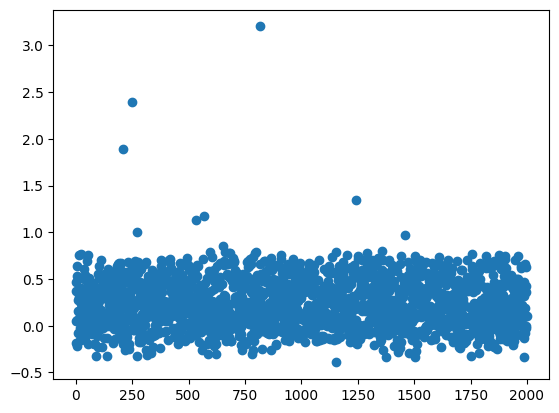

In [ ]:
# Calculate the total cost
df_costs['cost_total'] = df_costs['cost_long_freq']*weights[0] + \
                        df_costs['cost_all_freq']*weights[1] + \
                        df_costs['cost_nrdd']*weights[2]

plt.scatter(range(len(df_costs)), np.log10(df_costs['cost_total']));

In [193]:
df_costs_best = df_costs.sort_values(by='cost_total', ascending=True).head(10)
display(df_costs_best)

,cost_long_freq,cost_all_freq,cost_nrdd,cost_total
1152,5.916547e-06,0.000041,1.663318,0.404725
1377,2.071643e-07,0.000039,1.925555,0.459514
1502,4.869802e-06,0.000019,1.928382,0.463921
1988,3.039396e-05,0.000038,1.794506,0.465635
89,1.336676e-06,0.000101,1.933897,0.468976
1753,1.359224e-07,0.000008,2.003522,0.474830
273,1.914426e-06,0.000013,2.000049,0.476633
138,3.976359e-06,0.000211,1.908350,0.477052
316,3.964598e-07,0.000009,2.041600,0.484238
622,2.453088e-06,0.000075,2.041409,0.493278


In [ ]:
# DP with the minimal cost
idx_1152 = df_costs['cost_total'].idxmin()
print ('Index:', idx_1152)
df_params.loc[[idx_1152]]

Index: 1152


,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,disp_long_396,disp_long_397,disp_long_398,disp_long_399,sum_sensi,coupling_long,slot_2-2,slot_3-2,slot_4-1,slot_4-2
1152,2153,175.51,119.21,241.21,4,75.641,53.089,2,76.463,49.445,...,0.302489,0.297539,0.293608,0.290752,4.342749e-18,0.991657,0,0,0,1


<Axes: xlabel='cost_long_freq', ylabel='cost_nrdd'>

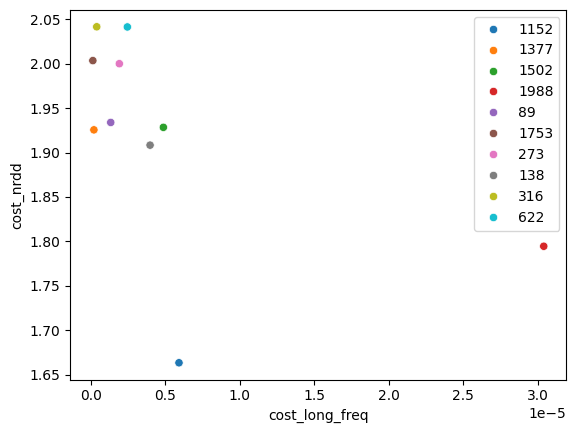

In [204]:
sns.scatterplot(data=df_costs_best, x='cost_long_freq', y='cost_nrdd', hue=[str(x) for x in df_costs_best.index])
plt.show()

<Axes: xlabel='cost_all_freq', ylabel='cost_nrdd'>

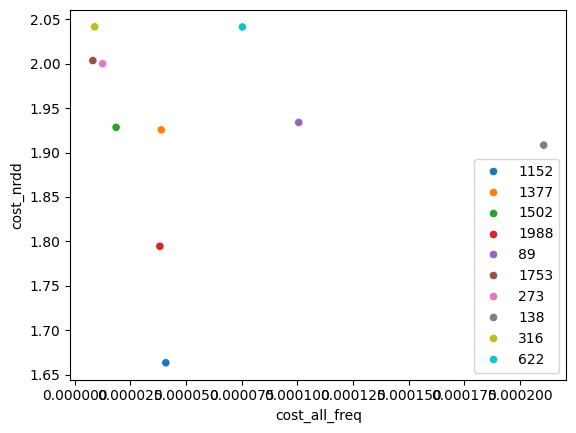

In [205]:
sns.scatterplot(data=df_costs_best, x='cost_all_freq', y='cost_nrdd', hue=[str(x) for x in df_costs_best.index])
plt.xticks(rotation=90)
plt.show()

In [216]:
# Initial guess = Index 1152
xvar_1152 = df_params.loc[idx_1152, lst_var]

res_nm = minimize(
            f_cost,
            x0=xvar_1152,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1152 = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_1152)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1152))
print('Cost all freq.:', f_cost_all_freq(xsol_1152))
print('Cost NRDD:', f_cost_nrdd(xsol_1152))

Success: False
Optimal x: [173.03619495 119.5749288  241.93153576  74.06864227  51.81455207
  74.00000347  50.67032322  12.63713707   9.21183879  10.90713641
   5.98463435   8.1480944   14.67274684   0.76566154   0.25619241
  30.34493854  60.79992804   4.34258956  24.87806577  69.77750202
   1.53057096]
Optimal cost: 0.3596900654801998
Cost long. freq.: 2.683461335351678e-08
Cost all freq.: 2.139553036784742e-05
Cost NRDD: 1.5117507


C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\725629785.py:4: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_nm = minimize(


In [213]:
# Initial guess = Index 1988
xvar_1988 = df_params.loc[1988, lst_var]

res_nm = minimize(
            f_cost,
            x0=xvar_1988,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1988 = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_1988)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1988))
print('Cost all freq.:', f_cost_all_freq(xsol_1988))
print('Cost NRDD:', f_cost_nrdd(xsol_1988))

Optimization terminated successfully.
         Current function value: 0.359942
         Iterations: 943
         Function evaluations: 1532
Success: True
Optimal x: [175.90052958 119.55155066 241.83887497  74.19711265  48.28356879
  78.94496119  49.14576935  19.40683468  19.92872506   7.27582763
  10.394822     7.78618877  10.64771863   0.84863256   0.91877207
  45.17799802  72.06316702   2.1982422   26.31372182  69.84014524
   1.75099886]
Optimal cost: 0.3599417171980746
Cost long. freq.: 1.8255814833460275e-08
Cost all freq.: 2.0207646409800884e-05
Cost NRDD: 1.5133555


In [217]:
# Initial guess = Index 1502
xvar_1502 = df_params.loc[1502, lst_var]

res_nm = minimize(
            f_cost,
            x0=xvar_1502,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1502 = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_1502)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1502))
print('Cost all freq.:', f_cost_all_freq(xsol_1502))
print('Cost NRDD:', f_cost_nrdd(xsol_1502))

Optimization terminated successfully.
         Current function value: 0.355509
         Iterations: 947
         Function evaluations: 1527
Success: True
Optimal x: [1.73878796e+02 1.19634704e+02 2.41924322e+02 7.54461135e+01
 4.48976027e+01 7.43100243e+01 5.06896261e+01 1.21103228e+01
 8.36505833e+00 1.98824457e+01 3.86642862e+00 1.20129568e+01
 1.00664859e+01 4.24549466e-01 2.20000569e-01 4.22173632e+01
 7.40765779e+01 2.67507359e+00 2.06290271e+01 6.14765185e+01
 3.56383638e+00]
Optimal cost: 0.35550884390225884
Cost long. freq.: 4.488272511088805e-10
Cost all freq.: 1.707841137282776e-05
Cost NRDD: 1.4960122


In [218]:
# Initial guess = Index 1377
xvar_1377 = df_params.loc[1377, lst_var]

res_nm = minimize(
            f_cost,
            x0=xvar_1377,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1377 = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_1377)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1377))
print('Cost all freq.:', f_cost_all_freq(xsol_1377))
print('Cost NRDD:', f_cost_nrdd(xsol_1377))

Success: False
Optimal x: [1.73425117e+02 1.19113131e+02 2.41993250e+02 7.40427328e+01
 5.04883528e+01 8.03381491e+01 5.06950014e+01 9.78140928e-01
 1.56035626e+01 4.28759661e+00 9.47786400e-01 1.78234441e+01
 9.75405928e+00 2.25373802e-01 1.67073433e+00 4.01239832e+01
 6.68971778e+01 1.07261564e-01 2.26856117e+01 6.20834043e+01
 3.27549772e+00]
Optimal cost: 0.3795877026860026
Cost long. freq.: 1.955768799458698e-09
Cost all freq.: 1.1661192972753207e-05
Cost NRDD: 1.600076


C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\794279976.py:4: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_nm = minimize(


In [219]:
print('Cost long. freq.:', f_cost_long_freq(xsol_de))
print('Cost all freq.:', f_cost_all_freq(xsol_de))
print('Cost NRDD:', f_cost_nrdd(xsol_de))

print('Cost long. freq.:', f_cost_long_freq(xsol_denm))
print('Cost all freq.:', f_cost_all_freq(xsol_denm))
print('Cost NRDD:', f_cost_nrdd(xsol_denm))

print('Cost long. freq.:', f_cost_long_freq(xsol_1152))
print('Cost all freq.:', f_cost_all_freq(xsol_1152))
print('Cost NRDD:', f_cost_nrdd(xsol_1152))

print('Cost long. freq.:', f_cost_long_freq(xsol_1988))
print('Cost all freq.:', f_cost_all_freq(xsol_1988))
print('Cost NRDD:', f_cost_nrdd(xsol_1988))

print('Cost long. freq.:', f_cost_long_freq(xsol_1502))
print('Cost all freq.:', f_cost_all_freq(xsol_1502))
print('Cost NRDD:', f_cost_nrdd(xsol_1502))

print('Cost long. freq.:', f_cost_long_freq(xsol_1377))
print('Cost all freq.:', f_cost_all_freq(xsol_1377))
print('Cost NRDD:', f_cost_nrdd(xsol_1377))

Cost long. freq.: 3.999854436807791e-07
Cost all freq.: 2.6246489707710803e-05
Cost NRDD: 1.4442105
Cost long. freq.: 1.9271591010569787e-09
Cost all freq.: 1.9069568287394166e-05
Cost NRDD: 1.4281838
Cost long. freq.: 2.683461335351678e-08
Cost all freq.: 2.139553036784742e-05
Cost NRDD: 1.5117507
Cost long. freq.: 1.8255814833460275e-08
Cost all freq.: 2.0207646409800884e-05
Cost NRDD: 1.5133555
Cost long. freq.: 4.488272511088805e-10
Cost all freq.: 1.707841137282776e-05
Cost NRDD: 1.4960122
Cost long. freq.: 1.955768799458698e-09
Cost all freq.: 1.1661192972753207e-05
Cost NRDD: 1.600076


In [225]:
# --> xsol_1502
x_1502 = f_xvar2x(xsol_1502, 4, 2)
f_long, f_all, id_long = fea_pred_freq(x_1502)
nrdd = fea_pred_nrdd(x_1502)
print ('Long. Freq:', f_long, '\n All freq.:', f_all, '\n Pos. Long.:', id_long, '\n NRDD:', nrdd)

Long. Freq: 20000.423710868923 
 All freq.: [15341.88741748 15568.64253336 15596.09181246 15787.86245885
 15749.69799113 15802.20462449 15896.35010774 15875.67778263
 15972.32978624 15965.39525542 16162.18975415 16467.2528436
 16496.95881272 17018.37647851 17495.06621696 17670.29997554
 17876.2212497  17928.92755723 18040.54097578 18301.62935399
 18385.38451483 18567.70343033 18632.14180054 18781.00659215
 18907.88364878 19084.69024443 19234.18391091 19409.48279466
 19821.28217208 20098.02660263 20596.69153497 21050.40219203
 21121.01184407 21440.96546647 22119.28039109 22411.69199698] 
 Pos. Long.: 29 
 NRDD: 1.4960122


In [226]:
# --> xsol_1377
x_1377 = f_xvar2x(xsol_1377, 4, 2)
f_long, f_all, id_long = fea_pred_freq(x_1377)
nrdd = fea_pred_nrdd(x_1377)
print ('Long. Freq:', f_long, '\n All freq.:', f_all, '\n Pos. Long.:', id_long, '\n NRDD:', nrdd)

Long. Freq: 20000.884481497706 
 All freq.: [14611.15871206 14790.46428652 14990.59165664 15394.41528188
 15517.85071885 15631.31641772 15644.72739191 15752.47333332
 15892.38171782 15919.76961904 16105.15241762 16406.2735249
 16386.82131214 16888.61111831 17295.33164792 17387.83541944
 17474.99505734 17615.16029525 17741.82934354 17848.10006375
 18216.1585592  18347.47418388 18482.61849584 18656.35031396
 18758.41202766 18902.6808341  19103.28956249 19387.26683623
 19735.77355848 19835.85298666 20155.64404529 20884.42597134
 21072.02611655 21393.55116627 21666.96921809 22119.35988889] 
 Pos. Long.: 30 
 NRDD: 1.600076


Weights: More focus on frequency isolation (f_all)

In [228]:
# Initial guess = Index 1502
# weights = [1231.584474722171, 98.77432910621594, 0.23650968885338094]
weights_01 = [1231.584474722171, 1000, 0.23650968885338094]

xvar_1502 = df_params.loc[1502, lst_var]

res_nm = minimize(
            f_cost,
            x0=xvar_1502,
            args=(weights_01, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1502_01 = res_nm.x
print('Success:', res_nm.success)
print('Optimal x:', xsol_1502_01)
print('Optimal cost:', res_nm.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1502_01))
print('Cost all freq.:', f_cost_all_freq(xsol_1502_01))
print('Cost NRDD:', f_cost_nrdd(xsol_1502_01))

Success: False
Optimal x: [173.01499938 118.47963537 241.60496219  74.0025701   47.45295562
  74.66104205  52.26577144   9.74075984   7.79846084   9.35033878
   2.92626985  16.31159335   7.64412012   0.41854943   0.86529179
  55.51878216  87.98583203   3.30580784  36.71468615  50.65766106
   3.56146582]
Optimal cost: 0.4183072329121625
Cost long. freq.: 5.524392558466111e-07
Cost all freq.: 1.7354650805039142e-05
Cost NRDD: 1.6924136


C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\912842190.py:8: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_nm = minimize(


In [229]:
# Predictions of xsol_1502_01
x_1502_01 = f_xvar2x(xsol_1502_01, 4, 2)
f_long, f_all, id_long = fea_pred_freq(x_1502_01)
nrdd = fea_pred_nrdd(x_1502_01)
print ('Long. Freq:', f_long, '\n All freq.:', f_all, '\n Pos. Long.:', id_long, '\n NRDD:', nrdd)

Long. Freq: 20014.865251506068 
 All freq.: [15235.50187224 15445.40057081 15602.96065372 15811.2813717
 15905.09828944 15948.54439265 16043.12581309 16092.09526256
 16116.51010098 16137.1009189  16285.14246069 16552.0822134
 16663.50631657 17234.17147382 17559.4922881  17633.62128289
 17784.28042288 17898.91011599 18051.76137343 18278.20837709
 18486.40482099 18638.19792369 18791.01990452 18852.30089021
 19037.55355596 19166.84576932 19276.73172533 19511.73141281
 19861.3819416  20191.51997717 20526.15669885 21140.90361709
 21243.96583726 21576.75202389 22189.76173267 22442.40780774] 
 Pos. Long.: 28 
 NRDD: 1.6924136


In [235]:
# Parameters of xsol_1502_01
pd.DataFrame(x_1502_01, index=lst_cols).sort_index()

,0
chamfer_x_dim_y,9.740760
chamfer_x_dim_z,7.798461
chamfer_y_dim_x,9.350339
chamfer_y_dim_z,2.926270
chamfer_z_dim_x,16.311593
chamfer_z_dim_y,7.644120
cut_x_depth,3.305808
cut_x_end,87.985832
cut_x_start,55.518782
cut_z_depth,3.561466


Check the "All frequencies" model with test dataset

In [261]:
lst_freq = lst_param[86:122]
Y_freq = df_params[lst_freq]
Y_freq_test = Y_freq.loc[idx_test]

pipe_tuned_allfreq = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_all_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_allfreq.score(X_test, Y_freq_test))

Y_freq_pred = pipe_tuned_allfreq.predict(X_test)
residuals = Y_freq_pred-Y_freq_test

Y_freq_pred = pd.DataFrame(Y_freq_pred, columns=Y_freq_test.columns, index=Y_freq_test.index)
residuals = pd.DataFrame(residuals, columns=Y_freq_test.columns, index=Y_freq_test.index)

Score of the test set: 0.9975845732050838


In [285]:
X_test.head()

,dim_x,dim_y,dim_z,slot_x_length,slot_x_distance,slot_z_length,slot_z_distance,chamfer_x_dim_y,chamfer_x_dim_z,chamfer_y_dim_x,...,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,seg_x_out,seg_z_out,slot_2-2,slot_3-2,slot_4-1,slot_4-2
4019,174.46,118.64,240.02,80.812,44.668,79.890,80.779,15.800,3.2052,0.84376,...,2.3208,43.998,66.495,3.1647,53.0080,87.2300,0,0,1,0
4694,176.67,124.99,240.45,77.107,51.113,82.891,79.422,14.008,1.9037,11.15200,...,3.4458,31.098,45.339,0.7832,43.5555,88.3350,0,0,1,0
2025,174.02,115.44,241.19,81.907,57.361,82.034,63.656,10.219,10.3500,6.34490,...,4.2527,35.879,51.131,1.8912,63.2340,55.1820,0,1,0,0
1152,175.51,119.21,241.21,75.641,53.089,76.463,49.445,11.367,8.8571,10.44800,...,4.4890,29.596,63.282,1.3673,40.9715,63.0325,0,0,0,1
1378,176.14,124.25,239.79,76.641,42.732,80.114,55.654,10.299,1.1467,11.67500,...,1.6879,25.620,65.053,1.5541,55.7970,60.2430,0,0,0,1


In [294]:
id_test = 1378
mode_no_long = 77
df_params.loc[[id_test], ['mode_no_long', 'freq_long', 'mode_mac_long']]

,mode_no_long,freq_long,mode_mac_long
1378,77,18975.39,0.964339


In [295]:
lst_modes = ['freq_' + str(x) for x in range(mode_no_long-5, mode_no_long+6)]
display(X_test.loc[[id_test]])
display(Y_freq_test.loc[[id_test], lst_modes])
display(Y_freq_pred.loc[[id_test], lst_modes])
display(residuals.loc[[id_test], lst_modes])

,dim_x,dim_y,dim_z,slot_x_length,slot_x_distance,slot_z_length,slot_z_distance,chamfer_x_dim_y,chamfer_x_dim_z,chamfer_y_dim_x,...,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,seg_x_out,seg_z_out,slot_2-2,slot_3-2,slot_4-1,slot_4-2
1378,176.14,124.25,239.79,76.641,42.732,80.114,55.654,10.299,1.1467,11.675,...,1.6879,25.62,65.053,1.5541,55.797,60.243,0,0,0,1


,freq_72,freq_73,freq_74,freq_75,freq_76,freq_77,freq_78,freq_79,freq_80,freq_81,freq_82
1378,18498.235,18619.737,18654.621,18878.497,18894.512,18975.39,18995.367,19436.451,20091.58,20230.085,20639.5


,freq_72,freq_73,freq_74,freq_75,freq_76,freq_77,freq_78,freq_79,freq_80,freq_81,freq_82
1378,18501.256714,18643.653067,18775.449675,18886.983421,19005.919386,19130.274463,19190.319889,19430.404276,20140.58087,20303.047522,20656.777809


,freq_72,freq_73,freq_74,freq_75,freq_76,freq_77,freq_78,freq_79,freq_80,freq_81,freq_82
1378,3.021714,23.916067,120.828675,8.486421,111.407386,154.884463,194.952889,-6.046724,49.00087,72.962522,17.277809


In [297]:
X_test.loc[id_test, lst_cols].sort_index()

chamfer_x_dim_y     10.29900
chamfer_x_dim_z      1.14670
chamfer_y_dim_x     11.67500
chamfer_y_dim_z      4.60310
chamfer_z_dim_x     16.93400
chamfer_z_dim_y     16.43300
cut_x_depth          1.68790
cut_x_end           91.31900
cut_x_start         47.96500
cut_z_depth          1.55410
cut_z_end           65.05300
cut_z_start         25.62000
dim_x              176.14000
dim_y              124.25000
dim_z              239.79000
elefoot_x            0.85884
elefoot_z            3.98350
seg_x_out           55.79700
seg_z_out           60.24300
slot_2-2             0.00000
slot_3-2             0.00000
slot_4-1             0.00000
slot_4-2             1.00000
slot_x_distance     42.73200
slot_x_length       76.64100
slot_z_distance     55.65400
slot_z_length       80.11400
Name: 1378, dtype: float64

Define a new cost function for the predicted frequencies:
* take the longitudinal frequency from pipe_tuned_longfreq, not from pipe_tuned_allfreq
* Squares apply directly on frequencies, not on the difference

In [335]:
def f_cost_all_freq_01(xvar, nb_slots_x=4, nb_slots_z=2):
    x = f_xvar2x(xvar, nb_slots_x, nb_slots_z)
    f_long, f_all, idx = fea_pred_freq(x)

    # Cost is calculated with the predicted frequencies: below, longitudinal, above
    #f0 = f_all[idx]
    #cost_f_below = (1/(f_all[idx-1]-f0))**2
    #cost_f_above = (1/(f_all[idx+1]-f0))**2

    # Both costs must be positive: f_all[idx-1] < f_long < f_all[idx+1] normally
    cost_f_below = abs(1/(f_all[idx-1]**2 - f_long**2))
    cost_f_above = abs(1/(f_all[idx+1]**2 - f_long**2))
    cost_f_all = cost_f_below + cost_f_above

    if not np.isfinite(cost_f_all):
        print("Non-finite cost detected!", xvar)
        return 1e9

    return cost_f_all

In [339]:
print (f_cost_long_freq(xvar_02))
print (f_cost_all_freq_01(xvar_02))
print (f_cost_nrdd(xvar_02))

5.916546600805831e-06
2.5138562999843437e-07
1.6633179


In [340]:
# Reinitialize the weights
weights = [1, 1, 1]

In [341]:
# Redefine the total cost function
def f_cost_01(xvar, weights, nb_slots_x=4, nb_slots_z=2):
    weight_f_long = weights[0]
    weight_f_all = weights[1]
    weight_nrdd = weights[2]
    cost = f_cost_long_freq(xvar, nb_slots_x, nb_slots_z)*weight_f_long + \
            f_cost_all_freq_01(xvar, nb_slots_x, nb_slots_z)*weight_f_all + \
            f_cost_nrdd(xvar, nb_slots_x, nb_slots_z)*weight_nrdd
    return cost

In [342]:
# Calculate the costs for all DP again with slot class 4-2
df_costs_01 = pd.DataFrame()

for id in idx_slots_4_2:
    print ('Index: ', id, ' / ', len(idx_slots_4_2)-1)
    lst_xvar = df_params.loc[id, lst_var].tolist()
    
    df_costs_01.loc[id, 'cost_long_freq'] = f_cost_long_freq(lst_xvar)
    df_costs_01.loc[id, 'cost_all_freq'] = f_cost_all_freq_01(lst_xvar)
    df_costs_01.loc[id, 'cost_nrdd'] = f_cost_nrdd(lst_xvar)

Index:  0  /  1999
Index:  1  /  1999
Index:  2  /  1999
Index:  3  /  1999
Index:  4  /  1999
Index:  5  /  1999
Index:  6  /  1999
Index:  7  /  1999
Index:  8  /  1999
Index:  9  /  1999
Index:  10  /  1999
Index:  11  /  1999
Index:  12  /  1999
Index:  13  /  1999
Index:  14  /  1999
Index:  15  /  1999
Index:  16  /  1999
Index:  17  /  1999
Index:  18  /  1999
Index:  19  /  1999
Index:  20  /  1999
Index:  21  /  1999
Index:  22  /  1999
Index:  23  /  1999
Index:  24  /  1999
Index:  25  /  1999
Index:  26  /  1999
Index:  27  /  1999
Index:  28  /  1999
Index:  29  /  1999
Index:  30  /  1999
Index:  31  /  1999
Index:  32  /  1999
Index:  33  /  1999
Index:  34  /  1999
Index:  35  /  1999
Index:  36  /  1999
Index:  37  /  1999
Index:  38  /  1999
Index:  39  /  1999
Index:  40  /  1999
Index:  41  /  1999
Index:  42  /  1999
Index:  43  /  1999
Index:  44  /  1999
Index:  45  /  1999
Index:  46  /  1999
Index:  47  /  1999
Index:  48  /  1999
Index:  49  /  1999
Index:  50

In [343]:
# Adjust the weights with the calculated costs
mean_cost_long_freq = df_costs_01['cost_long_freq'].mean()
mean_cost_all_freq = df_costs_01['cost_all_freq'].mean()
mean_cost_nrdd = df_costs_01['cost_nrdd'].mean()

print ('New weight (cost_long_freq):', 1/mean_cost_long_freq)
print ('New weight (cost_all_freq):', 1/mean_cost_all_freq)
print ('New weight (cost_nrdd):', 1/mean_cost_nrdd)

weights = [1/mean_cost_long_freq, 1/mean_cost_all_freq, 1/mean_cost_nrdd]

New weight (cost_long_freq): 1231.584474722171
New weight (cost_all_freq): 3423805.3954418674
New weight (cost_nrdd): 0.23650968885338094


In [349]:
df_costs_01['cost_total'] = df_costs_01['cost_long_freq']*weights[0] + \
                        df_costs_01['cost_all_freq']*weights[1] + \
                        df_costs_01['cost_nrdd']*weights[2]

In [344]:
# Find the global minimum of a multivariate function
# - Derivative-free optimizer)
# - Can search large areas of candidate space

res_de = differential_evolution(
            f_cost_01,
            args=(weights, 4, 2),  # constants
            bounds=var_bounds,
            maxiter=30,
            polish=False
        )
xsol_de = res_de.x
print('Success:', res_de.success)
print('Optimal x:', xsol_de)
print('Optimal cost:', res_de.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_de))
print('Cost all freq.:', f_cost_all_freq_01(xsol_de))
print('Cost NRDD:', f_cost_nrdd(xsol_de))

Success: False
Optimal x: [173.80332662 118.67782996 241.8656842   82.81823577  51.63430666
  78.28854651  52.69124578  19.79240443   7.17195166  17.50001468
   4.30427448   9.83398198   9.84510536   0.31586042   0.30777895
  50.22278623  66.21116362   1.34492888  34.16084763  61.80689215
   1.28962291]
Optimal cost: 0.6619663666918623
Cost long. freq.: 2.6754386785193316e-07
Cost all freq.: 7.942522261192456e-08
Cost NRDD: 1.6477141


In [352]:
# Minimization of scaler function using the Nelder-Mead algorithm
res_denm = minimize(
            f_cost_01,
            x0=xsol_de,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xvar_07 = res_denm.x
print('Success:', res_denm.success)
print('Optimal x:', xvar_07)
print('Optimal cost:', res_denm.fun)
print('Cost long. freq.:', f_cost_long_freq(xvar_07))
print('Cost all freq.:', f_cost_all_freq_01(xvar_07))
print('Cost NRDD:', f_cost_nrdd(xvar_07))

C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\2265616730.py:2: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_denm = minimize(


Success: False
Optimal x: [173.79500752 118.66861719 241.93810111  82.85355885  51.50954641
  78.12162646  52.52456588  19.81754985   7.16423997  17.77025298
   4.31124269   9.86809246   9.8929119    0.31513548   0.30719843
  49.45484943  66.30945654   1.35021571  33.86478779  61.53190709
   1.28928561]
Optimal cost: 0.6494989487317329
Cost long. freq.: 1.1750020040128688e-08
Cost all freq.: 7.630950061117608e-08
Cost NRDD: 1.6414363


In [ ]:
# Display the parameters for x_07, sorted alphabetically
x_07 = f_xvar2x(xvar_07, 4, 2)
pd.DataFrame(x_07, index=lst_cols).sort_index()

,0
chamfer_x_dim_y,19.817550
chamfer_x_dim_z,7.164240
chamfer_y_dim_x,17.770253
chamfer_y_dim_z,4.311243
chamfer_z_dim_x,9.868092
chamfer_z_dim_y,9.892912
cut_x_depth,1.350216
cut_x_end,66.309457
cut_x_start,49.454849
cut_z_depth,1.289286


Look at the best DP with the new total cost function and take some as initial guess

In [350]:
df_costs_01_best = df_costs_01.sort_values(by='cost_total', ascending=True).head(10)
display(df_costs_01_best)

,cost_long_freq,cost_all_freq,cost_nrdd,cost_total
1753,1.359224e-07,9.717659e-08,2.003522,0.806734
1428,1.313793e-05,8.750136e-08,2.130479,0.819647
316,3.964598e-07,1.022502e-07,2.041600,0.833431
864,1.948292e-05,8.525798e-08,2.240328,0.845761
343,1.914783e-06,7.975598e-08,2.495995,0.865754
1788,3.365916e-05,1.075642e-07,1.975014,0.876843
1479,2.039156e-06,1.096699e-07,2.122995,0.880109
586,3.302349e-06,1.151996e-07,2.071120,0.888328
1940,8.549945e-06,8.059559e-08,2.570197,0.894350
1854,5.227966e-05,9.076230e-08,2.217712,0.899650


In [351]:
# Initial guess
xvar_1753 = df_params.loc[1753, lst_var]

res_nm_1753 = minimize(
            f_cost_01,
            x0=xvar_1753,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1753 = res_nm_1753.x
print('Success:', res_nm_1753.success)
print('Optimal x:', res_nm_1753)
print('Optimal cost:', res_nm_1753.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1753))
print('Cost all freq.:', f_cost_all_freq_01(xsol_1753))
print('Cost NRDD:', f_cost_nrdd(xsol_1753))

Success: False
Optimal x:        message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.7658297198069249
             x: [ 1.766e+02  1.181e+02 ...  6.300e+01  2.518e+00]
           nit: 1000
          nfev: 1528
 final_simplex: (array([[ 1.766e+02,  1.181e+02, ...,  6.300e+01,
                         2.518e+00],
                       [ 1.766e+02,  1.181e+02, ...,  6.300e+01,
                         2.518e+00],
                       ...,
                       [ 1.766e+02,  1.181e+02, ...,  6.301e+01,
                         2.517e+00],
                       [ 1.766e+02,  1.181e+02, ...,  6.301e+01,
                         2.517e+00]]), array([ 7.658e-01,  7.658e-01, ...,  7.659e-01,  7.659e-01]))
Optimal cost: 0.7658297198069249
Cost long. freq.: 5.659010302727269e-08
Cost all freq.: 8.50851786971491e-08
Cost NRDD: 2.0060275


C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\2169764207.py:4: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_nm_1753 = minimize(


In [360]:
# Initial guess
xvar_1428 = df_params.loc[1428, lst_var]

res_nm_1428 = minimize(
            f_cost_01,
            x0=xvar_1428,
            args=(weights, 4, 2),  # constants
            method='Nelder-Mead',
            bounds=var_bounds,
            options={'disp': True, 'maxiter': 1000}
        )
xsol_1428 = res_nm_1428.x
print('Success:', res_nm_1428.success)
print('Optimal x:', xsol_1428)
print('Optimal cost:', res_nm_1428.fun)
print('Cost long. freq.:', f_cost_long_freq(xsol_1428))
print('Cost all freq.:', f_cost_all_freq_01(xsol_1428))
print('Cost NRDD:', f_cost_nrdd(xsol_1428))

Success: False
Optimal x: [175.98961039 119.69153608 241.68838115  78.96111778  51.00344631
  76.0606152   51.03419822  14.39842994  18.46090618   8.89517318
   0.94299949   7.10664271  17.25016871   2.96818688   1.10839638
  20.3640959   71.57518052   4.87370577  33.39905991  65.17072781
   0.83304251]
Optimal cost: 0.7694321818487155
Cost long. freq.: 5.488329978679148e-06
Cost all freq.: 8.593425190088819e-08
Cost NRDD: 1.9806828


C:\Users\fbrouet\AppData\Local\Temp\ipykernel_21800\541355473.py:4: RuntimeWarning: Maximum number of iterations has been exceeded.
  res_nm_1428 = minimize(
